# **Experiment Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT1",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT1/data


---
## Student Information


In [2]:
student_name = "Rose Marie Tazbaz"
student_id = "25742507"

In [3]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [5]:
# <Student to fill this section and then remove this comment>

### 0.b Import Packages

In [6]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

---
## A. Project Description


In [7]:
business_objective = "I work as a freelance consultant. My client, this car re-selling business' owner, came to me because he noticed that overseas, car re-sellers started offering a predicted re-sale price for car owners, which incremented their likeliness to sell their cars through them, as they really value having an estimation of how much money they could get when selling their cars. As this technology hasn't been incorporated in Australia yet, my client sees this as an additional service that could differentiate him within the market, hence, increase his business' demand. In summary, the goal of this project is to develop a set of machine learning regression models to accurately predict the re-sale price of used cars in the Australian market, using historical data on vehicle attributes (such as manufacturing year, mileage, engine capacity, brand, etc). The aim of this project is to minimize the Root Mean Squared Error (RMSE) to provide valuations that potentially reflect current market reality. The results could be used to help buyers and sellers make better decisions (optimizing their profits and minimizing purchase cost). For my client, this could increase his demands, because he could use the model to identify the best price to list cars so they can be sold quickly without being underpriced and/or having them in stock for too long. Buyers can use the predictions as a reference to check if the price a dealer or private seller is asking is fair or too expensive or if it is a good deal. If the results are accurate, it creates a fair market where cars are sold at the right price, building trust between sellers and buyers, and making transactions much faster. However, if the result are not accurate, for example, the model predicts a price that is too high, the seller will wait a long time and likely never sell the car, or on the contrary, if the model predicts a price that is too low, the owner loses money they should have earned, or they might feel cheated and take their business elsewhere, leaving the buyer with less purchase options."

In [8]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_objective', value=business_objective)

---
## B. Dataset Understanding (Global Interpretation)

In [9]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Load training data
try:
  training_df = pd.read_csv(at.folder_path / "vehicles_price_training.csv")
  validation_df = pd.read_csv(at.folder_path / "vehicles_price_validation.csv")
  testing_df = pd.read_csv(at.folder_path / "vehicles_price_testing.csv")
except Exception as e:
  print(e)

### B.1 Explore Training Set


> You can add more cells in this section

In [10]:
# Dimensions
nrows_train = training_df.shape[0]
ncols_train = training_df.shape[1]

print(nrows_train)
print(ncols_train)

8774
29


In [11]:
training_df.dtypes

,0
prefix,object
first_name,object
last_name,object
gender,object
phone_number,object
email,object
vehicle_description,object
vehicle_brand,object
manufacturing_year,float64
model_name,object


In [12]:
# Convert numerical columns
training_df['price'] = pd.to_numeric(training_df['price'], errors='coerce')
training_df['manufacturing_year'] = pd.to_numeric(training_df['manufacturing_year'], errors='coerce')
training_df['kilometres_driven'] = pd.to_numeric(training_df['kilometres_driven'], errors='coerce')

# Describe (for columns captured as numerical)
training_df[['price', 'manufacturing_year', 'kilometres_driven']].describe()

,price,manufacturing_year,kilometres_driven
count,8.767000e+03,8774.000000,8760.000000
mean,2.473302e+04,2012.463073,145973.718379
std,2.614887e+04,4.455097,72138.636618
min,8.800000e+01,1940.000000,1.000000
25%,1.399000e+04,2010.000000,93333.500000
50%,1.999000e+04,2014.000000,134551.000000
75%,2.978950e+04,2016.000000,188002.000000
max,1.500000e+06,2017.000000,533849.000000


In [13]:
# Some variables that can't be converted to numerical
engine_num_convert = pd.to_numeric(training_df['engine_capacity'], errors='coerce')
print("Can be converted:", engine_num_convert.notnull().sum())
print("Can't be converted:", engine_num_convert.isnull().sum())

fuel_num_convert = pd.to_numeric(training_df['fuel_consumption'], errors='coerce')
print("Can be converted:", fuel_num_convert.notnull().sum())
print("Can't be converted:", fuel_num_convert.isnull().sum())

Can be converted: 0
Can't be converted: 8774
Can be converted: 0
Can't be converted: 8774


In [14]:
missing_data = training_df.isnull().sum()
missing_percentage = (missing_data / training_df.shape[0]) * 100
missing_df = pd.DataFrame({'missing_count': missing_data, 'missing_percentage': missing_percentage})
missing_df.sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
prefix,2852,32.505129
seats,1103,12.571233
doors,1036,11.807613
body_type,197,2.245270
kilometres_driven,14,0.159562
price,7,0.079781
vehicle_type,2,0.022795
vehicle_brand,0,0.000000
email,0,0.000000
phone_number,0,0.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

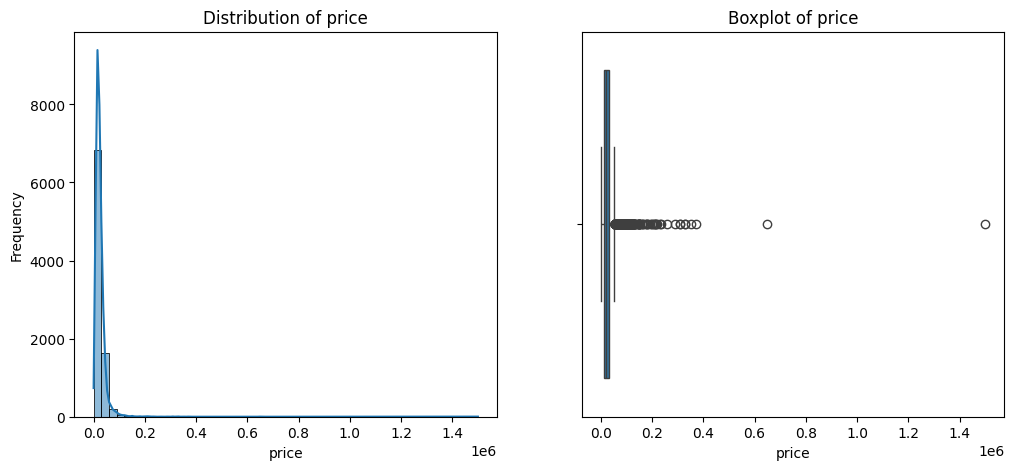

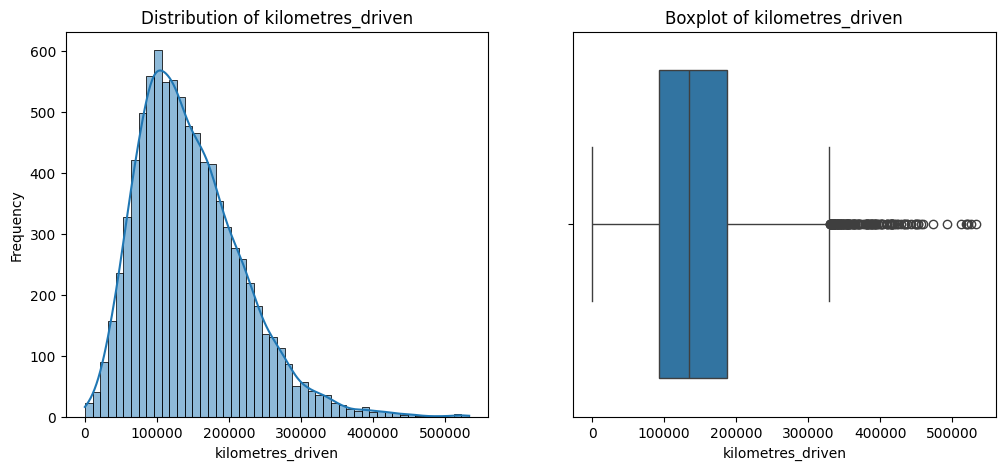

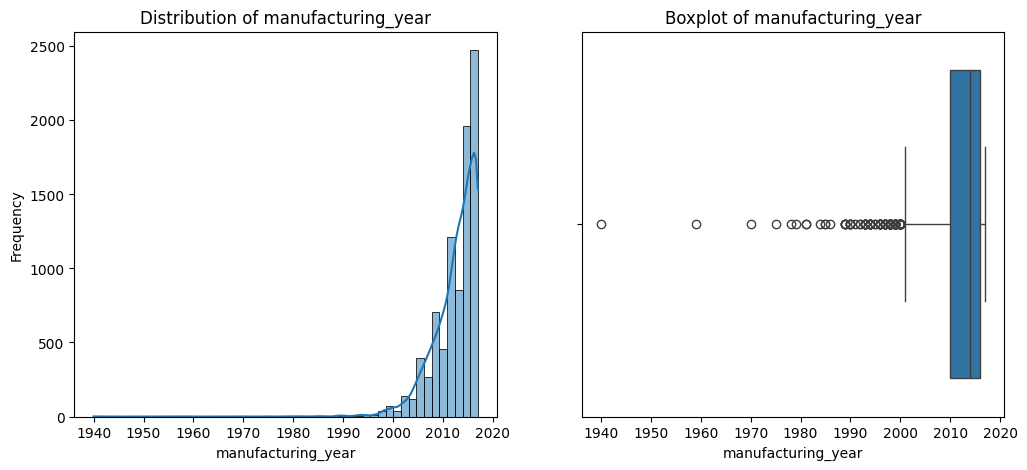

In [16]:
num_cols_to_plot = ['price', 'kilometres_driven', 'manufacturing_year']

for col in num_cols_to_plot:
    plt.figure(figsize=(12,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(training_df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=training_df[col])
    plt.title(f'Boxplot of {col}')

    plt.show()

Preliminar Correlation Matrix - training
price                 1.000000
manufacturing_year    0.104483
kilometres_driven    -0.265718
Name: price, dtype: float64


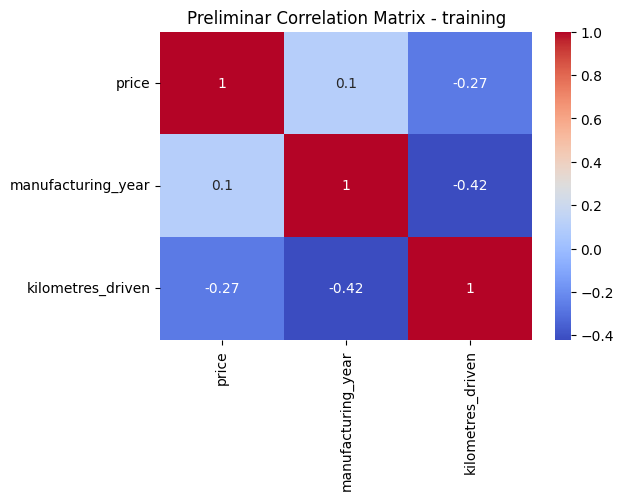

In [17]:
numeric_cols = ['price', 'manufacturing_year', 'kilometres_driven']  # some numerical columns in their correct format
corr_matrix = training_df[numeric_cols].corr()

print("Preliminar Correlation Matrix - training")
print(corr_matrix['price'].sort_values(ascending=False))

# Visualize
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Preliminar Correlation Matrix - training")
plt.show()

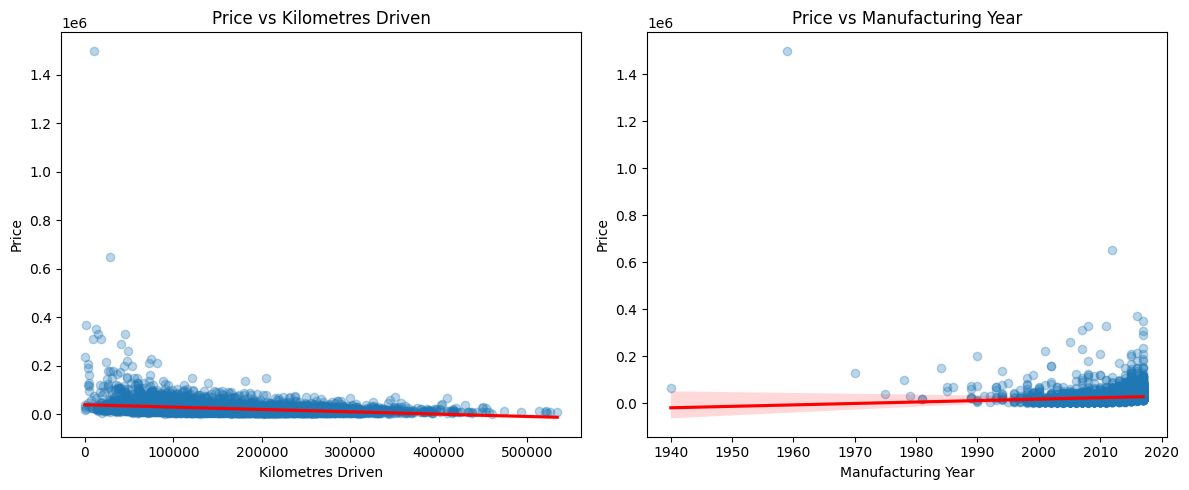

In [18]:
# Scatter plot for outlier detection

plt.figure(figsize=(12,5))

# Price and Kilometres Driven
plt.subplot(1,2,1)
sns.regplot(x='kilometres_driven', y='price', data=training_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Kilometres Driven')
plt.xlabel('Kilometres Driven')
plt.ylabel('Price')

# Price and Manufacturing Year
plt.subplot(1,2,2)
sns.regplot(x='manufacturing_year', y='price', data=training_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Manufacturing Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

In [19]:
training_set_insights = "The training dataset contains 8774 rows (observations) and 29 columns (features). All variables are stored as text (object), so we will need to address that issue and convert them so we can use them in our model. After transforming them to numerical columns, we can see that some of them are numbers but contain a specific format that needs to be assessed, for example, engine_capacity, fuel_consumption, etc. This explains why when calculating missing values, some features seem to have 100% of missing values, but it is not that they're actual missing values, but that the format is not correct.  In this project, the target variable (Y) is the column price. Some variables correspond to technical specifications (like engine_capacity, fuel_consumption or transmission_type), others are vehicle historical data (like manufacturing_year or kilometres_driven) and physical attributes (like body_type, vehicle_colour, etc). Other variables refer to the owner data/contact information, however, this information doesn't contribute to the market value of the car and also include private information, so they could be dropped for ethical/privacy reasons. The column vehicle_description overlaps with other features like vehicle_brand, manufacturing_year and model_name, as vehicle_description contains all other 3 variables. We can also see that price is right skewed (mean>median) while manufacturing_year is not really skewed and kilometres_driven is slightly right skewed. With a preliminar correlation matrix, we can see that manufacturing_year has a positive and very low correlation with price, possibly because with a larger manufacturing year (more new) the price tend to increase, however, it doesn't affect that much. Also, kilometers_driven has a negative moderate correlation, because with a larger mileage, the price tend to decrease. Using a scatter plot, I could recognize a low presence of outliers for these features."

In [20]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='training_set_insights', value=training_set_insights)

### B.2 Explore Validation Set

> You can add more cells in this section

In [21]:
# Dimensions
nrows_val = validation_df.shape[0]
ncols_val = validation_df.shape[1]

print(nrows_val)
print(ncols_val)

2615
29


In [22]:
validation_df.dtypes

,0
prefix,object
first_name,object
last_name,object
gender,object
phone_number,object
email,object
vehicle_description,object
vehicle_brand,object
manufacturing_year,float64
model_name,object


In [23]:
# Convert numerical columns
validation_df['price'] = pd.to_numeric(validation_df['price'], errors='coerce')
validation_df['manufacturing_year'] = pd.to_numeric(validation_df['manufacturing_year'], errors='coerce')
validation_df['kilometres_driven'] = pd.to_numeric(validation_df['kilometres_driven'], errors='coerce')

# Describe (for columns captured as numerical)
validation_df[['price', 'manufacturing_year', 'kilometres_driven']].describe()

,price,manufacturing_year,kilometres_driven
count,2614.000000,2615.000000,2615.000000
mean,43591.409334,2019.434034,60376.677247
std,32325.714985,0.495724,32933.686791
min,12990.000000,2019.000000,12.000000
25%,27990.000000,2019.000000,38961.000000
50%,35990.000000,2019.000000,55928.000000
75%,48990.000000,2020.000000,74815.500000
max,649880.000000,2020.000000,347128.000000


In [24]:
missing_data_val = validation_df.isnull().sum()
missing_percentage_val = (missing_data_val / validation_df.shape[0]) * 100

missing_df_val = pd.DataFrame({
    'missing_count': missing_data_val,
    'missing_percentage': missing_percentage_val
})

missing_df_val.sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
prefix,900,34.416826
seats,143,5.468451
doors,138,5.277247
body_type,30,1.147228
last_name,1,0.038241
price,1,0.038241
vehicle_description,0,0.000000
vehicle_brand,0,0.000000
manufacturing_year,0,0.000000
email,0,0.000000


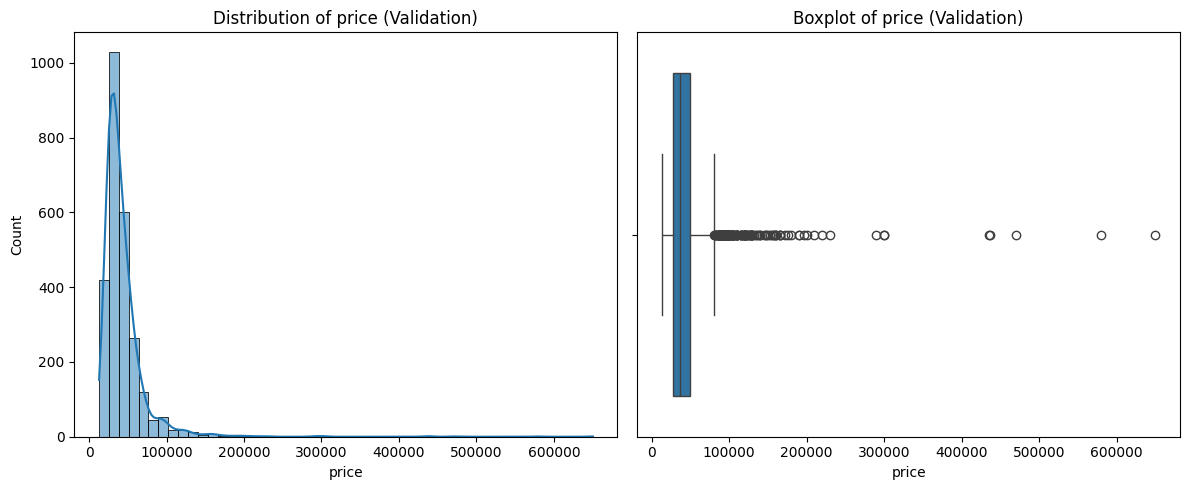

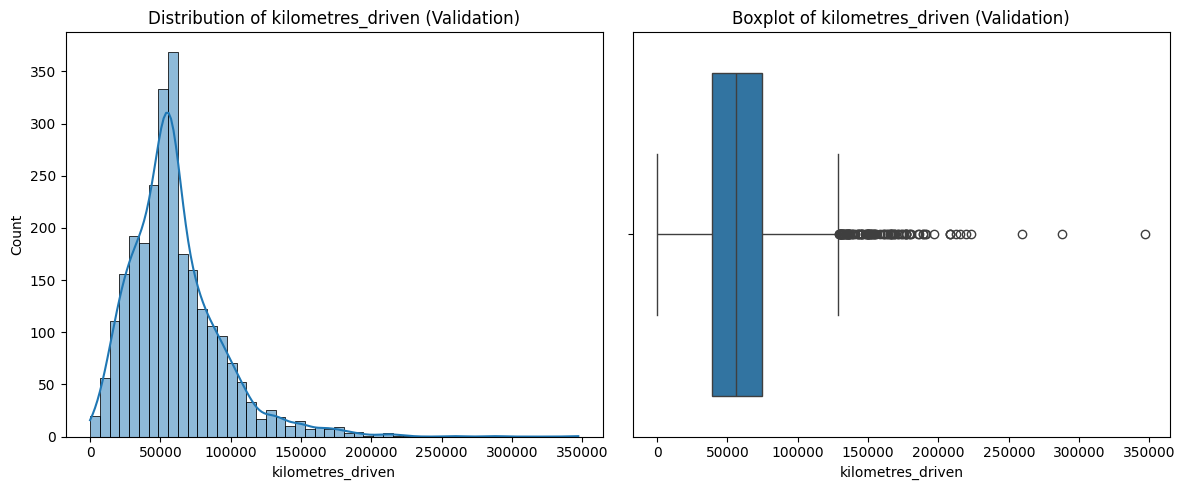

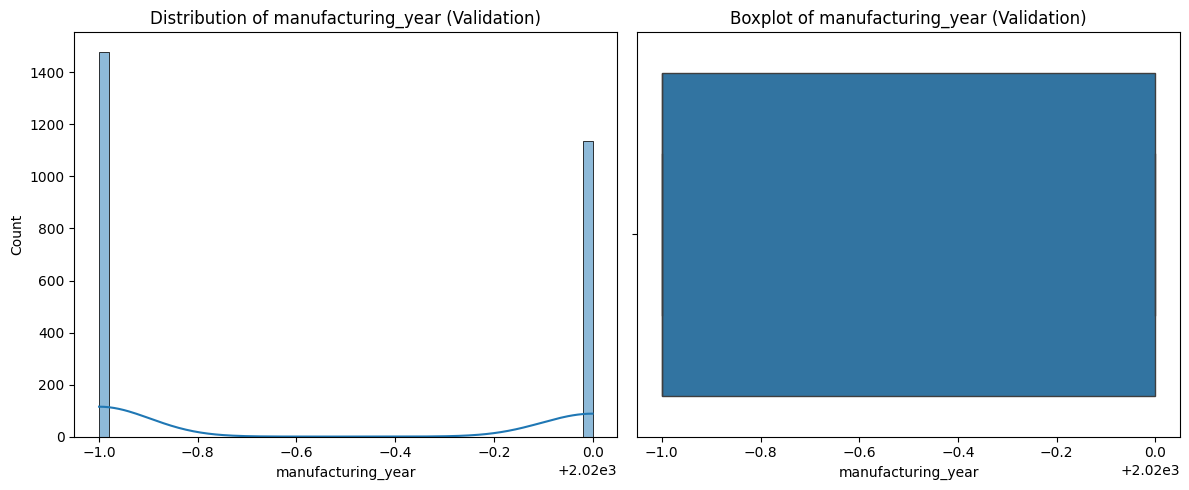

In [25]:
num_cols_to_plot = ['price', 'kilometres_driven', 'manufacturing_year']

for col in num_cols_to_plot:
    plt.figure(figsize=(12,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(validation_df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col} (Validation)')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=validation_df[col])
    plt.title(f'Boxplot of {col} (Validation)')

    plt.tight_layout()
    plt.show()

Preliminar Correlation Matrix - Validation
price                 1.000000
manufacturing_year    0.046800
kilometres_driven    -0.133836
Name: price, dtype: float64


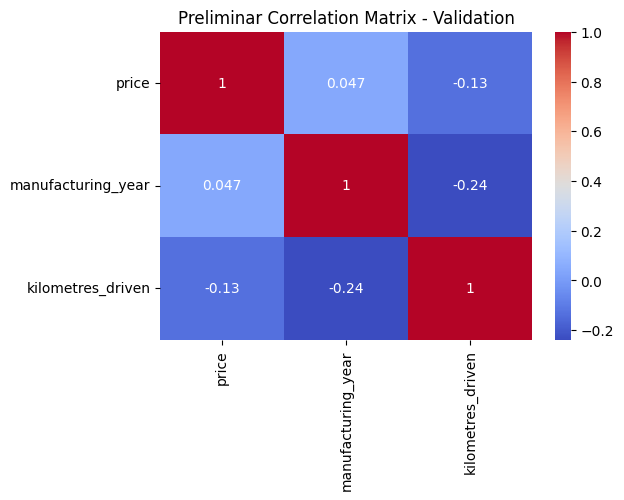

In [26]:
numeric_cols_val = ['price', 'manufacturing_year', 'kilometres_driven']

corr_matrix_val = validation_df[numeric_cols_val].corr()

print("Preliminar Correlation Matrix - Validation")
print(corr_matrix_val['price'].sort_values(ascending=False))

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix_val, annot=True, cmap='coolwarm')
plt.title("Preliminar Correlation Matrix - Validation")
plt.show()

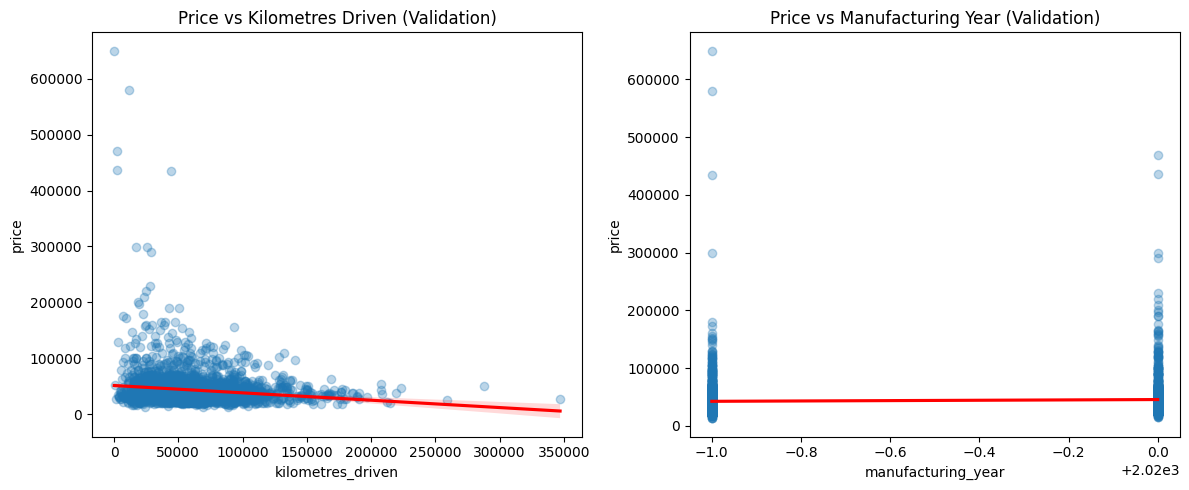

In [27]:
plt.figure(figsize=(12,5))

# Price and Kilometres Driven
plt.subplot(1,2,1)
sns.regplot(x='kilometres_driven', y='price', data=validation_df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Kilometres Driven (Validation)')

# Price and Manufacturing Year
plt.subplot(1,2,2)
sns.regplot(x='manufacturing_year', y='price', data=validation_df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Manufacturing Year (Validation)')

plt.tight_layout()
plt.show()

In [28]:
validation_set_insights = "The validation dataset contains 2615 rows (observations) and 29 columns (features). All variables are stored as text (object), so we will need to address that issue and convert them so we can use them in our model. After transforming them to numerical columns, we can see that some of them are numbers but contain a specific format that needs to be assessed, for example, engine_capacity, fuel_consumption, etc. This explains why when calculating missing values, some features seem to have 100% of missing values, but it is not that they're actual missing values, but that the format is not correct (same issues than the training set). In this project, the target variable (Y) is the column price. We can also see that price is right skewed (same as in the training set) while kilometres_driven is slightly right-skewed and manufacturing_year is not skewed, but distributed among both left and rights extremes. With a preliminar correlation matrix, we can see that manufacturing_year has a positive and very low correlation with price (slightly lower than for the training set), possibly because with a larger manufacturing year (more new) the price tend to increase, however, it doesn't affect that much (same as in the training set). Also, kilometers_driven has a negative low correlation (around half the impact than it has in the training set), because with a larger mileage, the price tend to decrease. Using a scatter plot, I could recognize a moderate presence of outliers for these features, and they are more frequent than in the training set."

In [29]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='validation_set_insights', value=validation_set_insights)

### B.3 Explore Testing Set

> You can add more cells in this section

In [30]:
# Dimensions
nrows_test = testing_df.shape[0]
ncols_test = testing_df.shape[1]

print(nrows_test)
print(ncols_test)

2647
29


In [31]:
testing_df.dtypes

,0
prefix,object
first_name,object
last_name,object
gender,object
phone_number,object
email,object
vehicle_description,object
vehicle_brand,object
manufacturing_year,float64
model_name,object


In [32]:
# Convert numerical columns
testing_df['price'] = pd.to_numeric(testing_df['price'], errors='coerce')
testing_df['manufacturing_year'] = pd.to_numeric(testing_df['manufacturing_year'], errors='coerce')
testing_df['kilometres_driven'] = pd.to_numeric(testing_df['kilometres_driven'], errors='coerce')

# Describe (for columns captured as numerical)
testing_df[['price', 'manufacturing_year', 'kilometres_driven']].describe()

,price,manufacturing_year,kilometres_driven
count,2606.000000,2647.000000,2070.000000
mean,67668.994628,2022.498300,4976.790821
std,56098.387320,0.500092,8251.972930
min,15900.000000,2022.000000,1.000000
25%,40290.000000,2022.000000,15.000000
50%,52606.500000,2022.000000,721.000000
75%,72357.500000,2023.000000,6841.000000
max,610000.000000,2023.000000,53960.000000


In [33]:
missing_data_test = testing_df.isnull().sum()
missing_percentage_test = (missing_data_test / testing_df.shape[0]) * 100

missing_df_test = pd.DataFrame({
    'missing_count': missing_data_test,
    'missing_percentage': missing_percentage_test
})

missing_df_test.sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
prefix,862,32.565168
kilometres_driven,577,21.798262
location,449,16.962599
seats,300,11.333585
doors,283,10.691349
price,41,1.548923
vehicle_type,25,0.944465
body_type,22,0.831130
email,0,0.000000
phone_number,0,0.000000


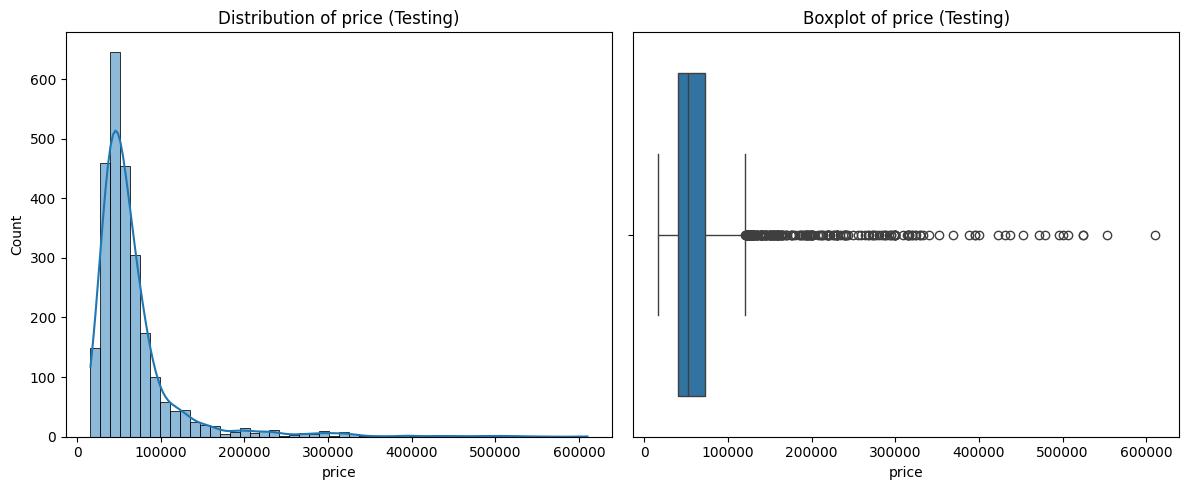

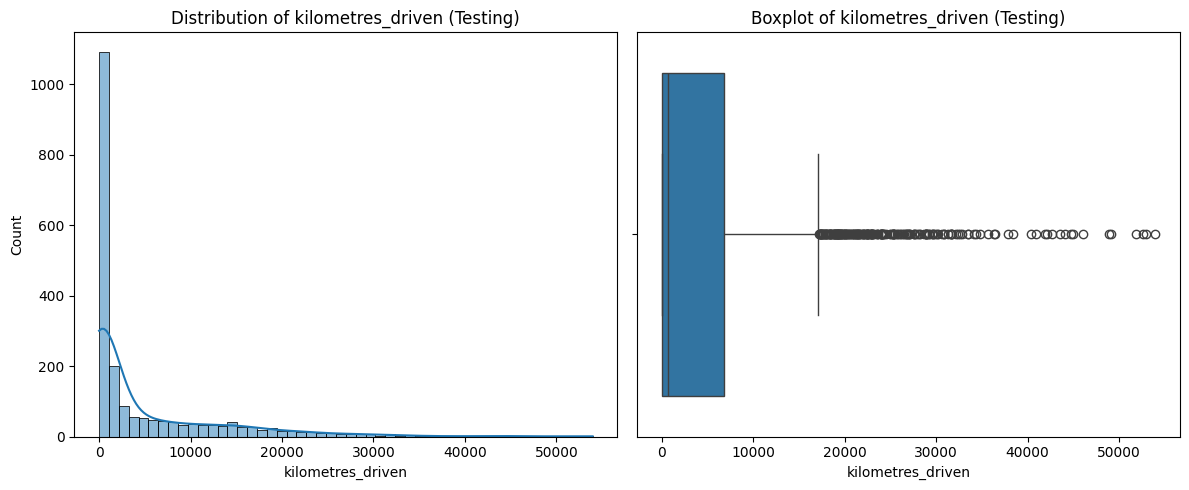

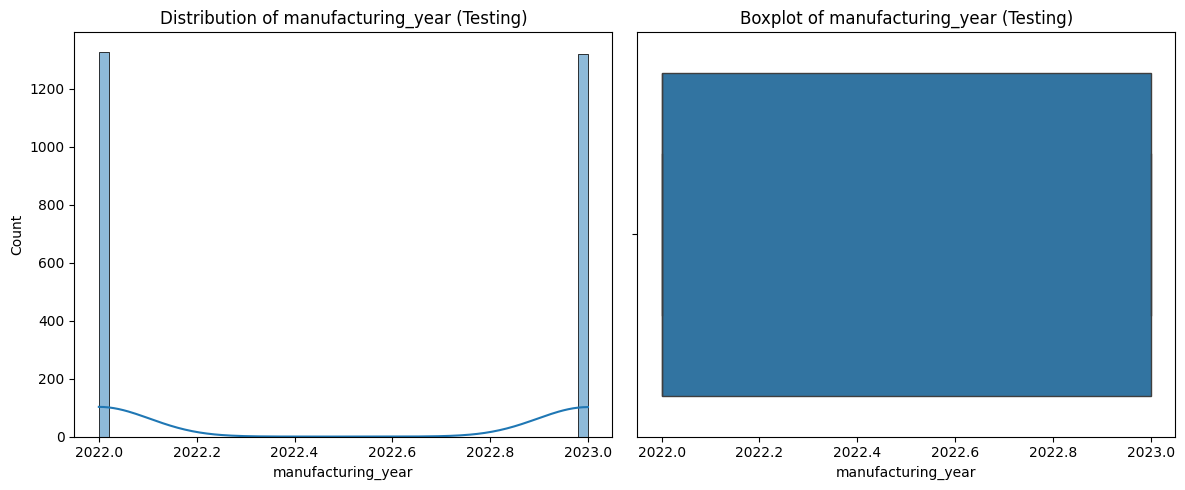

In [34]:
num_cols_to_plot = ['price', 'kilometres_driven', 'manufacturing_year']

for col in num_cols_to_plot:
    plt.figure(figsize=(12,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(testing_df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col} (Testing)')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=testing_df[col])
    plt.title(f'Boxplot of {col} (Testing)')

    plt.tight_layout()
    plt.show()

Preliminar Correlation Matrix - Testing
price                 1.000000
manufacturing_year    0.144932
kilometres_driven    -0.017830
Name: price, dtype: float64


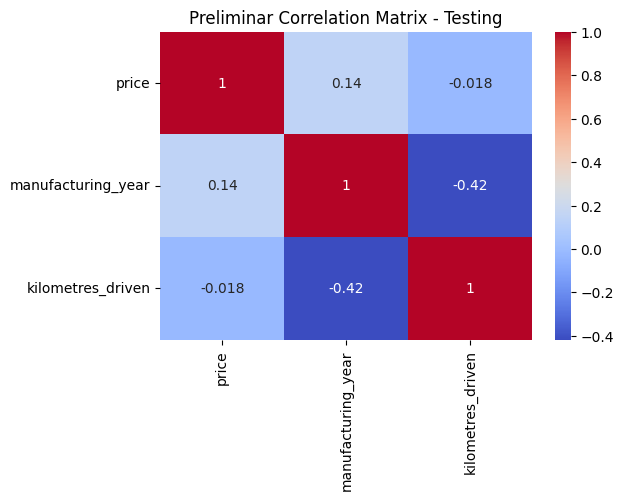

In [35]:
numeric_cols_test = ['price', 'manufacturing_year', 'kilometres_driven']

corr_matrix_test = testing_df[numeric_cols_test].corr()

print("Preliminar Correlation Matrix - Testing")
print(corr_matrix_test['price'].sort_values(ascending=False))

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix_test, annot=True, cmap='coolwarm')
plt.title("Preliminar Correlation Matrix - Testing")
plt.show()

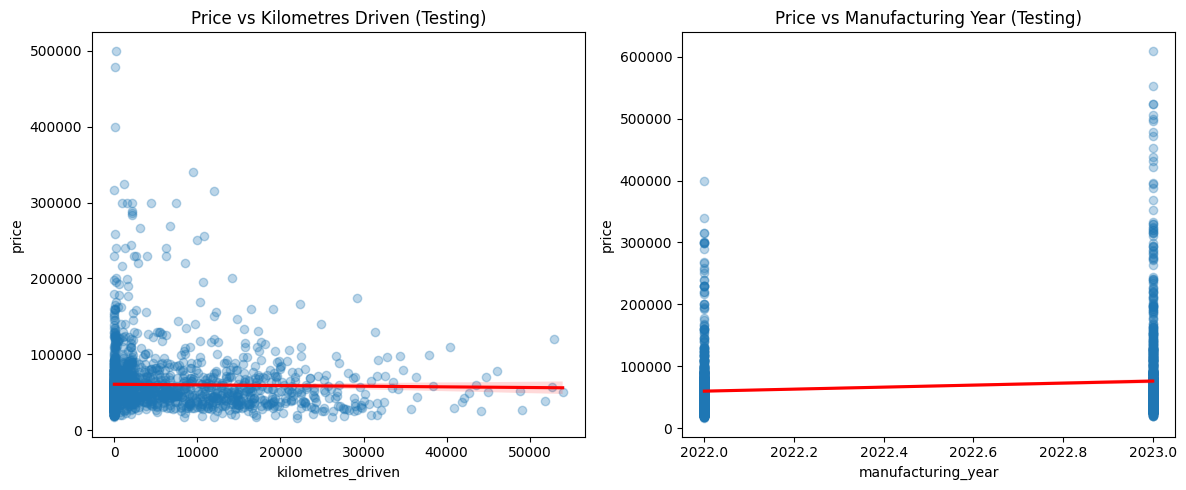

In [36]:
plt.figure(figsize=(12,5))

# Price and Kilometres Driven
plt.subplot(1,2,1)
sns.regplot(x='kilometres_driven', y='price', data=testing_df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Kilometres Driven (Testing)')

# Price and Manufacturing Year
plt.subplot(1,2,2)
sns.regplot(x='manufacturing_year', y='price', data=testing_df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price vs Manufacturing Year (Testing)')

plt.tight_layout()
plt.show()

In [37]:
testing_set_insights = "The testing dataset contains 2647 rows (observations) and 29 columns (features). All variables are stored as text (object), so we will need to address that issue and convert them so we can use them in our model. After transforming them to numerical columns, we can see that some of them are numbers but contain a specific format that needs to be assessed, for example, engine_capacity, fuel_consumption, etc. This explains why when calculating missing values, some features seem to have 100% of missing values, but it is not that they're actual missing values, but that the format is not correct (same issues than the training set). In this project, the target variable (Y) is the column price. We can also see that price is right-skewed (same as in the training and validation set), kilometres_driven is highly right-skewed, while manufacturing_year is not skewed, but distributed among both left and rights extremes (same as in the validation set. With a preliminar correlation matrix, we can see that manufacturing_year has a positive and low correlation with price (slightly larger than for the training set and much larger than the validation set), possibly because with a larger manufacturing year (more new) the price tend to increase, however, it doesn't affect that much (same as in the training and validation set). Also, kilometers_driven has a negative low correlation (higher impact than in the validation set but lower than in the training set, because with a larger mileage, the price tend to decrease. Using a scatter plot, I could recognize a low presence of outliers for these features, observations are more spread for price vs kilometres_driven and manufacturing_year."

In [38]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='testing_set_insights', value=testing_set_insights)

---
## C. Feature Understanding (Local Interpretation)

### C.1 Explore Target Variable

> Save the name of column used as the target variable and call it `target_name`

> You can add more cells in this section

In [39]:
target_name = 'price'

In [40]:
# Target variable summary
print("Target Variable Summary - Training Set")

training_target = training_df[target_name]

print(training_target.describe())

print("\nAdditional statistics:")
print("Mean:", training_target.mean())
print("Median:", training_target.median())
print("Standard deviation:", training_target.std())
print("Skewness:", training_target.skew())

# Check extremely high prices (outliers)
print("\nPercentiles:")
print(training_target.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Target Variable Summary - Training Set
count    8.767000e+03
mean     2.473302e+04
std      2.614887e+04
min      8.800000e+01
25%      1.399000e+04
50%      1.999000e+04
75%      2.978950e+04
max      1.500000e+06
Name: price, dtype: float64

Additional statistics:
Mean: 24733.02087373104
Median: 19990.0
Standard deviation: 26148.874929905425
Skewness: 24.50533827677577

Percentiles:
0.01     4999.00
0.05     7949.30
0.25    13990.00
0.50    19990.00
0.75    29789.50
0.95    51990.00
0.99    97121.16
Name: price, dtype: float64


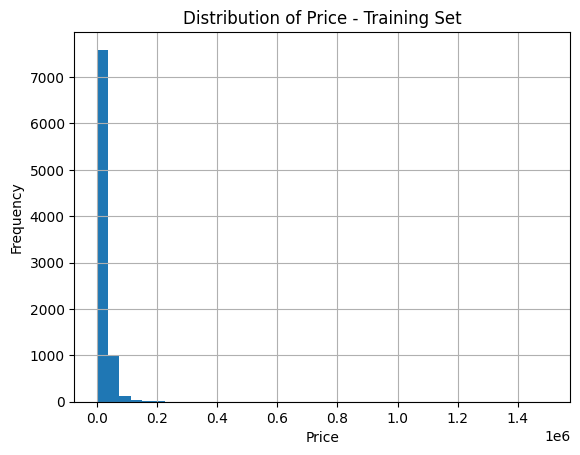

In [41]:
# Histogram
plt.figure()
training_target.hist(bins=40)
plt.title("Distribution of Price - Training Set")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

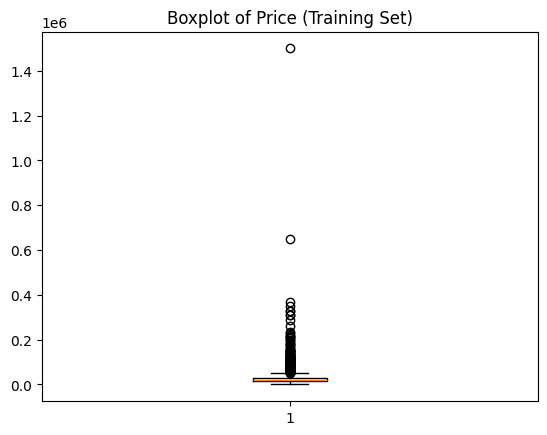

In [42]:
# Boxplot for outliers
plt.figure()
plt.boxplot(training_target.dropna())
plt.title("Boxplot of Price (Training Set)")
plt.show()

In [43]:
# IQR for outliers
Q1 = training_target.quantile(0.25)
Q3 = training_target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = training_target[(training_target < lower_bound) |
                           (training_target > upper_bound)]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(training_target) * 100)

Number of outliers: 418
Percentage of outliers: 4.764075678139959


In [44]:
# Using log
import numpy as np
training_df["log_price"] = np.log1p(training_target)

print("Original skewness:", training_target.skew())
print("Log-transformed skewness:", training_df["log_price"].skew())

Original skewness: 24.50533827677577
Log-transformed skewness: 0.1662310427507353


Target Variable Summary Across Splits
             count          mean           std      min      25%      50%  \
Training    8767.0  24733.020874  26148.874930     88.0  13990.0  19990.0   
Validation  2614.0  43591.409334  32325.714985  12990.0  27990.0  35990.0   
Testing     2606.0  67668.994628  56098.387320  15900.0  40290.0  52606.5   

                75%        max  
Training    29789.5  1500000.0  
Validation  48990.0   649880.0  
Testing     72357.5   610000.0  


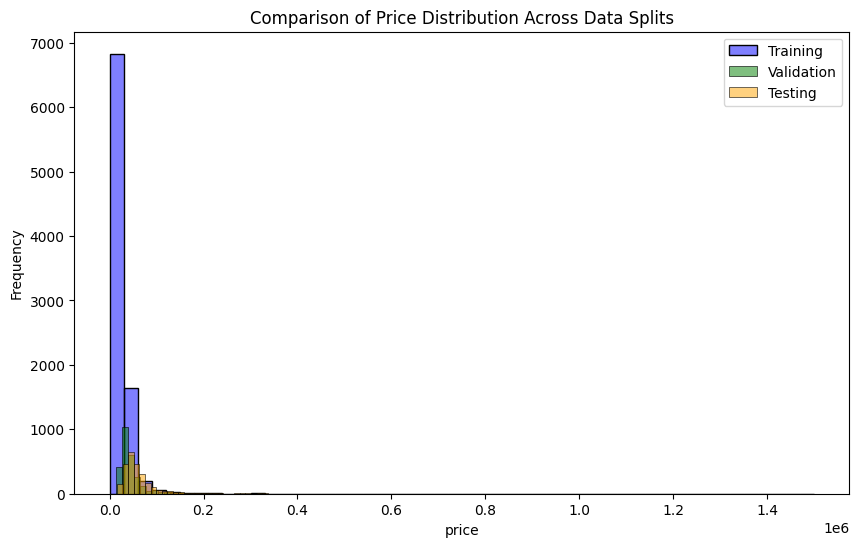

In [45]:
comparison_table = pd.DataFrame({
    'Training': training_df[target_name].describe(),
    'Validation': validation_df[target_name].describe(),
    'Testing': testing_df[target_name].describe()
}).T

print("Target Variable Summary Across Splits")
print(comparison_table)

# Plot
plt.figure(figsize=(10,6))
sns.histplot(training_df[target_name], bins=50, color='blue', alpha=0.5, label='Training')
sns.histplot(validation_df[target_name], bins=50, color='green', alpha=0.5, label='Validation')
sns.histplot(testing_df[target_name], bins=50, color='orange', alpha=0.5, label='Testing')
plt.xlabel(target_name)
plt.ylabel('Frequency')
plt.title('Comparison of Price Distribution Across Data Splits')
plt.legend()
plt.show()

In [46]:
target_insights = "The target variable contains 8767 observations in the training set. The mean price is 24.733, while the median is 19.990. As the mean is notably higher than the median, we can infere that the distribution is not symmetric and is influenced by higher-value vehicles. This is confirmed by the extremely high skewness value (24.51), indicating a heavily right-skewed distribution. Although most vehicles are concentrated in a moderate price range (between approximately 14.000 and 30.000 based on the interquartile range), there is a long right tail driven by a small number of very expensive cars. The maximum price reaches 1.500.000, which is dramatically larger than the 99th percentile (97,121), suggesting the presence of extreme outliers. The percentile analysis reinforces this observation. While 95% of vehicles are priced below 51,990, and 99% are below approximately 97,000, a few exceptional values push the maximum far beyond this range. The boxplot further highlights this pattern, showing a large number of upper-end outliers and two particularly extreme observations. Using the IQR method, 418 observations (approximately 4.76% of the dataset) are identified as outliers. Although this percentage is not excessively large, the magnitude of the extreme values significantly impacts the distribution’s shape and increases the standard deviation (26,148), which is even larger than the mean. Given this strong positive skewness, a logarithmic transformation was evaluated. After applying a log transformation, the skewness dropped dramatically from 24.51 to 0.17, indicating that the distribution becomes approximately symmetric. This suggests that modeling the log-transformed price may lead to more stable variance and improved performance, particularly for linear models. In summary, the price variable is heavily right-skewed due to extreme high-value vehicles, which introduces potential challenges such as sensitivity to outliers and heteroscedasticity. A logarithmic transformation appears to effectively address these issues and should be strongly considered in the modeling phase. When comparing the target variable price, it shows notable differences across the data splits. The training set has a lower mean and median with a very high maximum, indicating the presence of extreme outliers. The validation set has higher central values (mean and median), while the testing set is even higher (mean and median). This suggests that the validation and testing sets contain generally more expensive vehicles compared to the training set. While all splits retain a similar overall pattern of most vehicles in the lower-to-mid price range with a long tail of high-priced cars, the differences in central tendency indicate that the model may face challenges generalizing from training to validation/testing. Some adjustments may need to be done before modeling."

In [47]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='target_insights', value=target_insights)

### C.2 Explore Feature of Interest `kilometres_driven`

> You can add more cells in this section

Summary Statistics - Training Set
count      8760.000000
mean     145973.718379
std       72138.636618
min           1.000000
25%       93333.500000
50%      134551.000000
75%      188002.000000
max      533849.000000
Name: kilometres_driven, dtype: float64

Additional statistics:
Mean: 145973.71837899543
Median: 134551.0
Standard deviation: 72138.63661829405
Skewness: 0.8982188603344629

Percentiles:
0.01     25454.69
0.05     48870.15
0.25     93333.50
0.50    134551.00
0.75    188002.00
0.95    276545.65
0.99    357457.69
Name: kilometres_driven, dtype: float64

Number of outliers: 162
Percentage of outliers: 1.85%


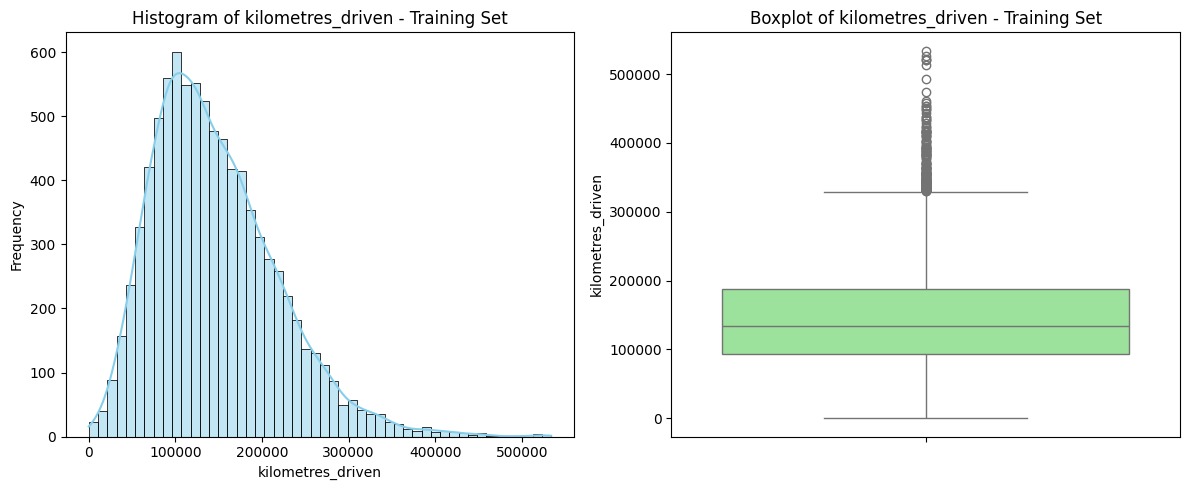

In [48]:
feature_kmd = 'kilometres_driven'

# Convert to numerical
training_df[feature_kmd] = pd.to_numeric(training_df[feature_kmd], errors='coerce')

# Descriptive statistics
desc_stats = training_df[feature_kmd].describe()
print("Summary Statistics - Training Set")
print(desc_stats)

# Additional calculations
mean_kmd = training_df[feature_kmd].mean()
median_kmd = training_df[feature_kmd].median()
std_kmd = training_df[feature_kmd].std()
skew_kmd = training_df[feature_kmd].skew()

print("\nAdditional statistics:")
print(f"Mean: {mean_kmd}")
print(f"Median: {median_kmd}")
print(f"Standard deviation: {std_kmd}")
print(f"Skewness: {skew_kmd}")

# Percentiles that are relevant
percentiles_kmd = training_df[feature_kmd].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print("\nPercentiles:")
print(percentiles_kmd)

# Identify outliers using IQR
Q1_kmd = desc_stats['25%']
Q3_kmd = desc_stats['75%']
IQR_kmd = Q3_kmd - Q1_kmd
lower_bound_kmd = Q1_kmd - 1.5 * IQR_kmd
upper_bound_kmd = Q3_kmd + 1.5 * IQR_kmd
outliers_kmd = training_df[(training_df[feature_kmd] < lower_bound_kmd) | (training_df[feature_kmd] > upper_bound_kmd)]
num_outliers_kmd = outliers_kmd.shape[0]
perc_outliers_kmd = (num_outliers_kmd / training_df.shape[0]) * 100

print(f"\nNumber of outliers: {num_outliers_kmd}")
print(f"Percentage of outliers: {perc_outliers_kmd:.2f}%")

# Visualization
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(training_df[feature_kmd], bins=50, kde=True, color='skyblue')
plt.title(f'Histogram of {feature_kmd} - Training Set')
plt.xlabel(feature_kmd)
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(y=training_df[feature_kmd], color='lightgreen')
plt.title(f'Boxplot of {feature_kmd} - Training Set')

plt.tight_layout()
plt.show()

In [49]:
feature_1_insights = "The feature kilometres_driven shows how much each vehicle has been driven. The mean mileage is about 146,000 km, slightly higher than the median of 135,000 km, which indicates a moderate right-skewed distribution (with skewness of around 0.9). Most vehicles are in the 93,000–188,000 km range (25%–75% percentile), while a small number of cars have extremely high mileage up to 533,849 km, considered outliers (about 1.85% of the data). The histogram shows most cars have mileage below 200,000 km, with a long tail of higher-mileage vehicles. The boxplot confirms these outliers. For modeling, this feature may be transformed to reduce the effect of extreme values on regression models."

In [50]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.3 Explore Feature of Interest `manufacturing_year`

> You can add more cells in this section

Summary Statistics - Training Set
count    8774.000000
mean     2012.463073
std         4.455097
min      1940.000000
25%      2010.000000
50%      2014.000000
75%      2016.000000
max      2017.000000
Name: manufacturing_year, dtype: float64

Additional statistics:
Mean: 2012.4630727148392
Median: 2014.0
Standard deviation: 4.455097037244246
Skewness: -2.2735563951661484

Percentiles:
0.01    1998.0
0.05    2004.0
0.25    2010.0
0.50    2014.0
0.75    2016.0
0.95    2017.0
0.99    2017.0
Name: manufacturing_year, dtype: float64

Number of outliers: 163
Percentage of outliers: 1.86%


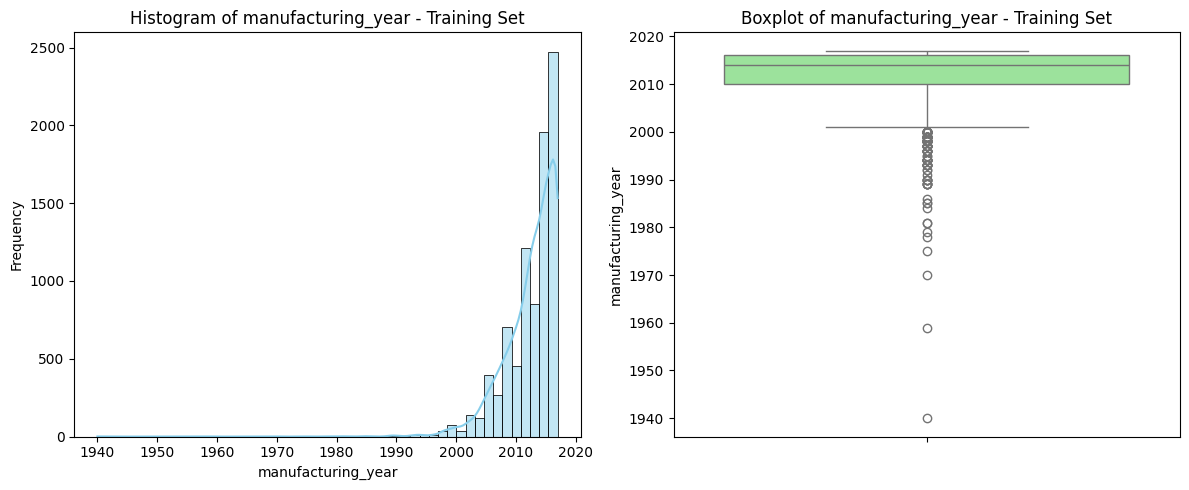

In [51]:
feature_my = 'manufacturing_year'

# Convert to numerical
training_df[feature_my] = pd.to_numeric(training_df[feature_my], errors='coerce')

# Descriptive statistics
desc_stats = training_df[feature_my].describe()
print("Summary Statistics - Training Set")
print(desc_stats)

# Additional calculations
mean_my = training_df[feature_my].mean()
median_my = training_df[feature_my].median()
std_my = training_df[feature_my].std()
skew_my = training_df[feature_my].skew()

print("\nAdditional statistics:")
print(f"Mean: {mean_my}")
print(f"Median: {median_my}")
print(f"Standard deviation: {std_my}")
print(f"Skewness: {skew_my}")

# Percentiles that are relevant
percentiles_my = training_df[feature_my].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print("\nPercentiles:")
print(percentiles_my)

# Identify outliers using IQR
Q1_my = desc_stats['25%']
Q3_my = desc_stats['75%']
IQR_my = Q3_my - Q1_my
lower_bound_my = Q1_my - 1.5 * IQR_my
upper_bound_my = Q3_my + 1.5 * IQR_my
outliers_my = training_df[(training_df[feature_my] < lower_bound_my) | (training_df[feature_my] > upper_bound_my)]
num_outliers_my = outliers_my.shape[0]
perc_outliers_my = (num_outliers_my / training_df.shape[0]) * 100

print(f"\nNumber of outliers: {num_outliers_my}")
print(f"Percentage of outliers: {perc_outliers_my:.2f}%")

# Visualization
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(training_df[feature_my], bins=50, kde=True, color='skyblue')
plt.title(f'Histogram of {feature_my} - Training Set')
plt.xlabel(feature_my)
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(y=training_df[feature_my], color='lightgreen')
plt.title(f'Boxplot of {feature_my} - Training Set')

plt.tight_layout()
plt.show()

In [52]:
feature_2_insights = "The feature manufacturing_year shows the year each vehicle was made. The mean year is 2012, slightly lower than the median of 2014, and the distribution has a negative skew (skewness of around -2.3), meaning there are a few older cars pulling the tail to the left. Most vehicles were manufactured between 2010 and 2016 (25%–75% percentile), with the oldest cars from 1940 and the newest in 2017. There are 163 outliers (about 1.86%, almost same numbers than kilometres_driven, which can be corelated, we will explore it later), mostly very old cars. The histogram shows a strong concentration of newer vehicles and a small number of much older cars. This feature is fairly clean and numeric, so it can be used directly in modeling, though extreme old cars might need attention if they disproportionately affect regression results."

In [53]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.4 Explore Feature of Interest `vehicle_brand`

> You can add more cells in this section

Top 10 vehicle brands by frequency:
 vehicle_brand
Toyota           1430
Holden            916
Ford              682
Nissan            667
Mazda             619
Hyundai           605
Mitsubishi        542
Mercedes-Benz     388
Volkswagen        386
Subaru            335
Name: count, dtype: int64

Price statistics by brand (top 10 brands):
                count          mean   median           std     min       max  \
vehicle_brand                                                                 
Toyota          1428  26634.516106  23990.0  15860.808760  2500.0  105990.0   
Holden           916  19352.979258  15494.5  12907.667323  2999.0  148880.0   
Ford             682  23627.318182  18965.0  18360.611825  2500.0  234990.0   
Nissan           666  21010.171171  18775.0  13124.565382  2995.0  138880.0   
Mazda            618  19032.163430  17985.0   8152.985869  1200.0   44999.0   
Hyundai          605  18191.786777  17886.0   6835.848354  2650.0   38999.0   
Mitsubishi       542  2101

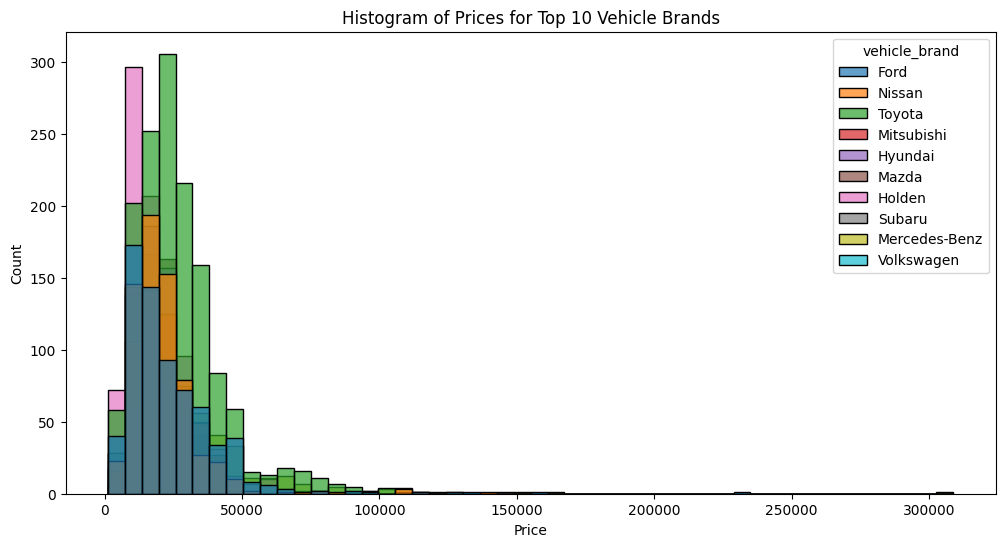

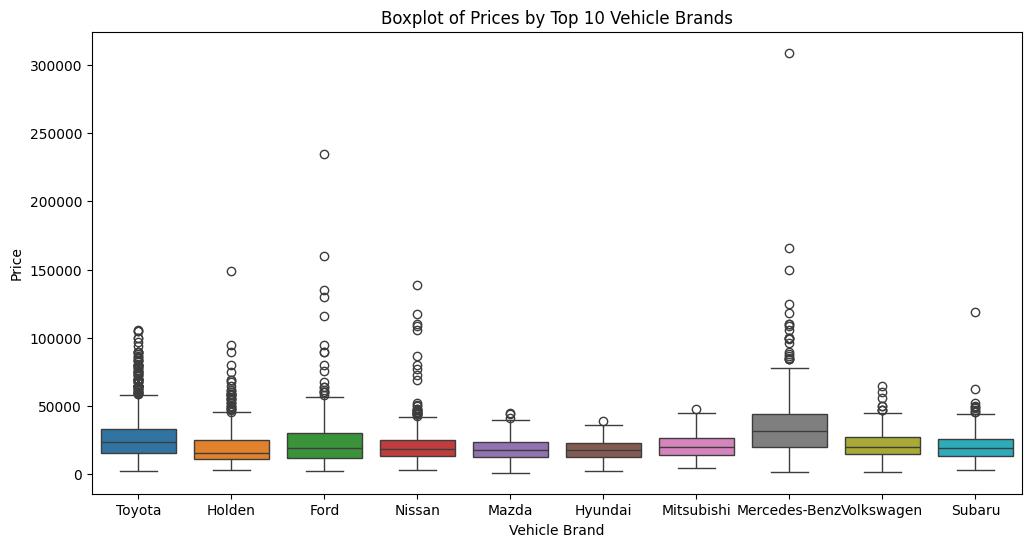

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

feature_vb = 'vehicle_brand'

# Brand frequency
brand_counts = training_df[feature_vb].value_counts()
top_brands = brand_counts.head(10).index.tolist()
print("Top 10 vehicle brands by frequency:\n", brand_counts.head(10))

# Price statistics by brand
brand_price_stats = training_df.groupby(feature_vb)['price'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

# Skewness per brand
brand_price_stats['skewness'] = training_df.groupby(feature_vb)['price'].apply(lambda x: skew(x.dropna()))
print("\nPrice statistics by brand (top 10 brands):\n", brand_price_stats.loc[top_brands])

# Outlier detection with IQR
def calculate_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers

brand_outliers = training_df.groupby(feature_vb)['price'].apply(calculate_outliers)
outlier_counts = brand_outliers.loc[top_brands].groupby(feature_vb).count()
print("\nNumber of outliers per brand (top 10 brands):\n", outlier_counts)

# Visualize top 10 brands only
top_brand_df = training_df[training_df[feature_vb].isin(top_brands)]

# Histogram of prices (top 10 brands)
top_brand_df = training_df[training_df[feature_vb].isin(top_brands)].copy()

# Histogram of prices for top 10 brands
plt.figure(figsize=(12,6))
sns.histplot(data=top_brand_df, x='price', hue='vehicle_brand', bins=50, alpha=0.7, palette="tab10")
plt.title("Histogram of Prices for Top 10 Vehicle Brands")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Boxplot of prices by brand
plt.figure(figsize=(12,6))
sns.boxplot(data=top_brand_df, x='vehicle_brand', y='price', order=top_brands, palette="tab10")
plt.title("Boxplot of Prices by Top 10 Vehicle Brands")
plt.xlabel("Vehicle Brand")
plt.ylabel("Price")
plt.show()


In [55]:
feature_3_insights = "The top 10 most frequent vehicle brands in the dataset are Toyota, Holden, Ford, Nissan, Mazda, Hyundai, Mitsubishi, Mercedes-Benz, Volkswagen, and Subaru, with Toyota being the most common with 1,430 cars. Looking at price statistics by brand, I noticed big differences: mean prices vary a lot, from around 18,000–19,000 AUD for Hyundai and Mazda to over 36,000 AUD for Mercedes-Benz. Median prices are generally slightly lower than the means, showing some high-price outliers skewing the averages upward, especially for brands like Ford, Nissan, and Mercedes-Benz. This was confirmed with skewness, because most brands have positive skew, meaning there are some extremely high-priced cars compared to the majority of listings. For example, Ford (4.15), Mercedes-Benz (3.82), and Nissan (3.80) are heavily right-skewed. Brands like Hyundai (0.21) and Mazda (0.59) are much more symmetric. On the other hand Toyota has the largest amount of outliers (73 cars), followed by Holden (34) and Nissan (27). Some brands like Hyundai and Mitsubishi have very few outliers, indicating more consistent pricing. This could mean that brand affects price significantly, probably luxury or premium brands like Mercedes-Benz have much higher mean prices, while mass-market brands like Hyundai and Mazda are cheaper. Also, high skewness in many brands suggests a few very expensive cars drive up the average, so median might be a more robust measure of typical price. Finally, I think that outliers are important to consider when modeling, because they can influence predictions."

In [56]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.n Explore Feature of Interest `vehicle_type`

> You can add more cells related to other feeatures in this section

Top 10 vehicle types by frequency:
 vehicle_type
SUV               2905
Hatchback         1350
Sedan             1309
Ute / Tray        1236
Wagon              397
USED Dealer ad     225
Commercial         205
Coupe              183
Convertible         87
Nippon Motors       53
Name: count, dtype: int64

Price statistics by vehicle type (top 10 types):
                 count          mean   median           std      min       max  \
vehicle_type                                                                    
SUV              2904  25656.211777  21995.0  15675.762577   3200.0  152990.0   
Hatchback        1349  16031.573017  14980.0   7859.560716   1200.0   69880.0   
Sedan            1309  22373.896868  15999.0  21968.529900     88.0  329990.0   
Ute / Tray       1235  27245.923887  24999.0  14231.317281   2995.0  208800.0   
Wagon             397  20809.130982  16888.0  15165.469032   2995.0  149500.0   
USED Dealer ad    224  28021.084821  21997.0  25242.511465   2050.0  198880.0

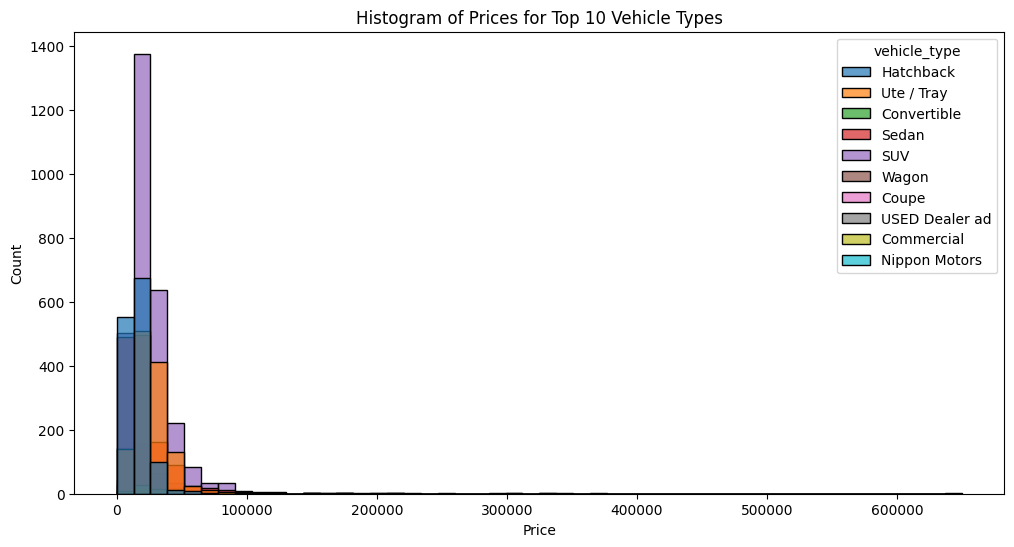

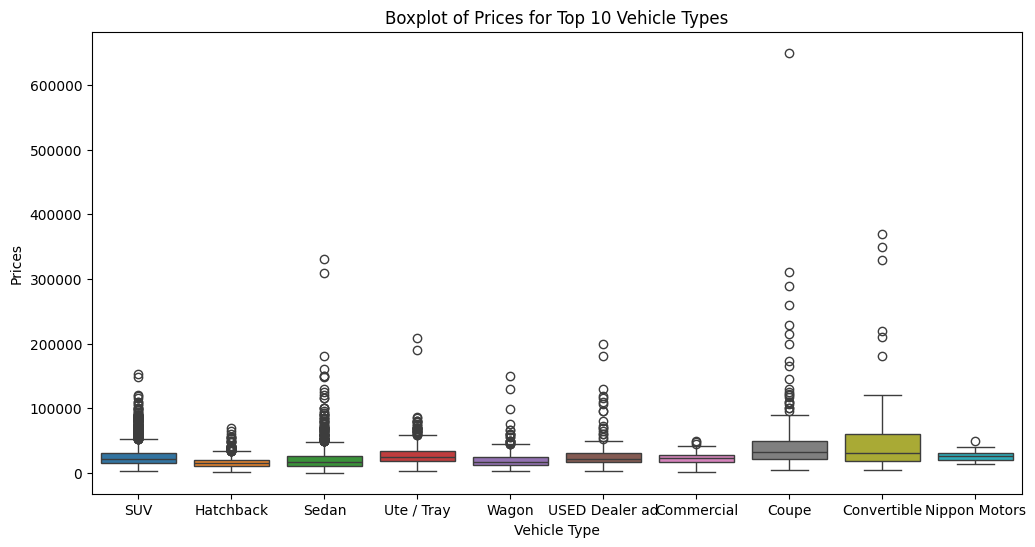

In [57]:
import pandas as pd
import numpy as np
import altair as alt
from scipy.stats import skew

feature_vt = 'vehicle_type'

# Vehicle type frequency
type_counts = training_df[feature_vt].value_counts()
top_types = type_counts.head(10).index.tolist()  # We choose top 10 types for visualization

print("Top 10 vehicle types by frequency:\n", type_counts.head(10))

# Price statistics by vehicle type
type_price_stats = training_df.groupby(feature_vt)['price'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

# Skewness per type
type_price_stats['skewness'] = training_df.groupby(feature_vt)['price'].apply(lambda x: skew(x.dropna()))

print("\nPrice statistics by vehicle type (top 10 types):\n", type_price_stats.loc[top_types])

# Outlier detection using IQR
def calculate_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers

type_outliers = training_df.groupby(feature_vt)['price'].apply(calculate_outliers)
outlier_counts = type_outliers.loc[top_types].groupby(feature_vt).count()
print("\nNumber of outliers per vehicle type (top 10 types):\n", outlier_counts)

# Visualize
# Filter top vehicle types only
top_type_df = training_df[training_df[feature_vt].isin(top_types)].copy()

# Histogram of prices for top 10 vehicle types
plt.figure(figsize=(12,6))
sns.histplot(data=top_type_df, x='price', hue='vehicle_type', bins=50, alpha=0.7, palette="tab10")
plt.title("Histogram of Prices for Top 10 Vehicle Types")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Boxplot of prices by vehicle type
plt.figure(figsize=(12,6))
sns.boxplot(data=top_type_df, x='vehicle_type', y='price', order=top_types, palette="tab10")
plt.title("Boxplot of Prices for Top 10 Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Prices")
plt.show()

In [58]:
feature_n_insights = "The training dataset shows that SUVs are the most common vehicle type (2,905 cars), followed by hatchbacks (1,350) and sedans (1,309). Other types like coupes and convertibles are much less frequent. maybe because of their price or practicality. Looking at price statistics, we can see that different vehicle types have very different price ranges: for example, SUVs have a mean price around 25,656 AUD, median 21,995 AUD, and a moderate number of outliers (170). Sedans show a higher skew (5.67), meaning some very expensive models drive up the mean (mean 22,374 vs median 15,999). Also, coupes and convertibles have the highest mean prices (50,003 and 54,783 AUD), with strong skewness and many outliers, indicating wide variability in prices, and hatchbacks and Utes / Trays have lower mean prices but still display some skew, with outliers mostly at the high end. In general, Skewness is positive for most types, meaning most vehicles are priced lower than the few extremely expensive models. Commercial vehicles and Nippon Motors are less skewed, suggesting a more consistent price range. Overall, vehicle type clearly affects price, with SUVs and Utes being popular but moderately priced, and luxury types like coupes and convertibles showing high price variability. This insight could help in market analysis and pricing strategies in the modeling phase."

In [59]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=fbbefce8-41ae-47c6-bc64-96decd566c0b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>